<a href="https://colab.research.google.com/github/Manas-Siddharth/Deep-Learning/blob/main/binary_cnn_cats_dogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New Section

In [ ]:
!pip install -q datasets


README.md:   0%|          | 0.00/2.03k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/753 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  182MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 45.8MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/8000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Training images: (8000, 150, 150, 3)
Testing images: (2000, 150, 150, 3)


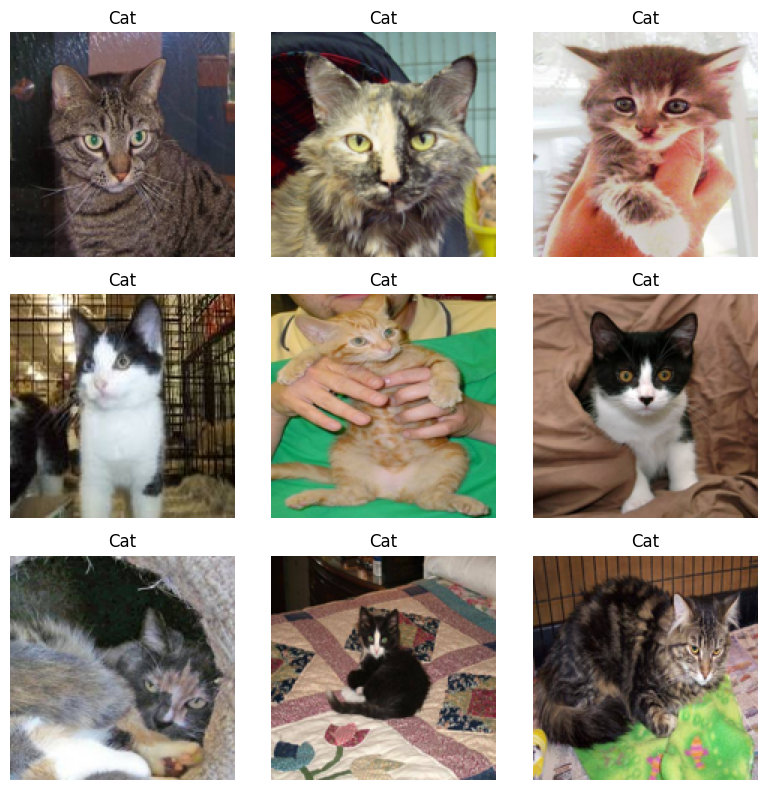

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 301s 1s/step - accuracy: 0.6389 - loss: 0.6636 - val_accuracy: 0.2894 - val_loss: 0.9053
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 282s 1s/step - accuracy: 0.6992 - loss: 0.5786 - val_accuracy: 0.3644 - val_loss: 0.9090
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 286s 1s/step - accuracy: 0.7555 - loss: 0.5025 - val_accuracy: 0.5400 - val_loss: 0.8023
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 315s 1s/step - accuracy: 0.8059 - loss: 0.4191 - val_accuracy: 0.6637 - val_loss: 0.6644
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 326s 1s/step - accuracy: 0.8495 - loss: 0.3382 - val_accuracy: 0.6612 - val_loss: 0.7069
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 321s 1s/step - accuracy: 0.8936 - loss: 0.2552 - val_accuracy: 0.7094 - val_loss: 0.7428
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 283s 1s/step - accuracy: 0.9356 - loss: 0.1662 - val_accuracy: 0.7125 - val_loss: 0.8884
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 324s 1s/step - accuracy: 0.9639 - loss: 0.0994 - val_accu

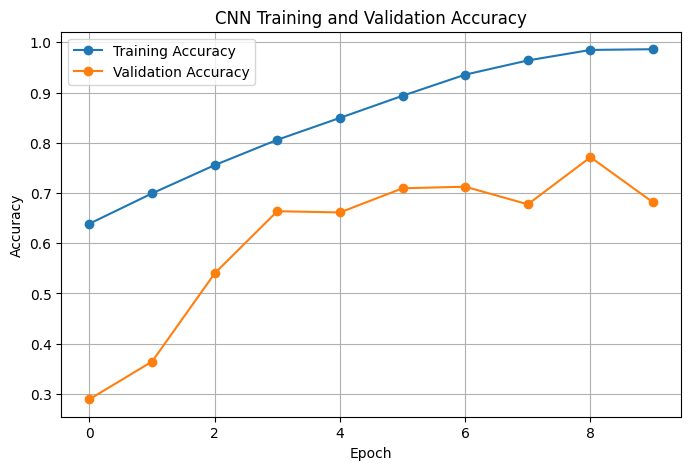

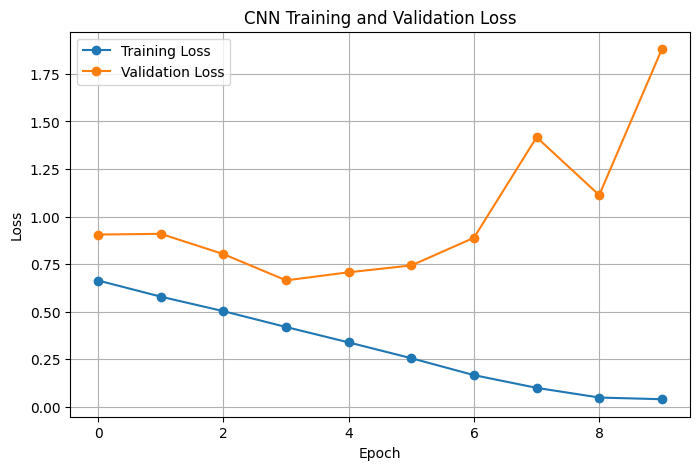

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step


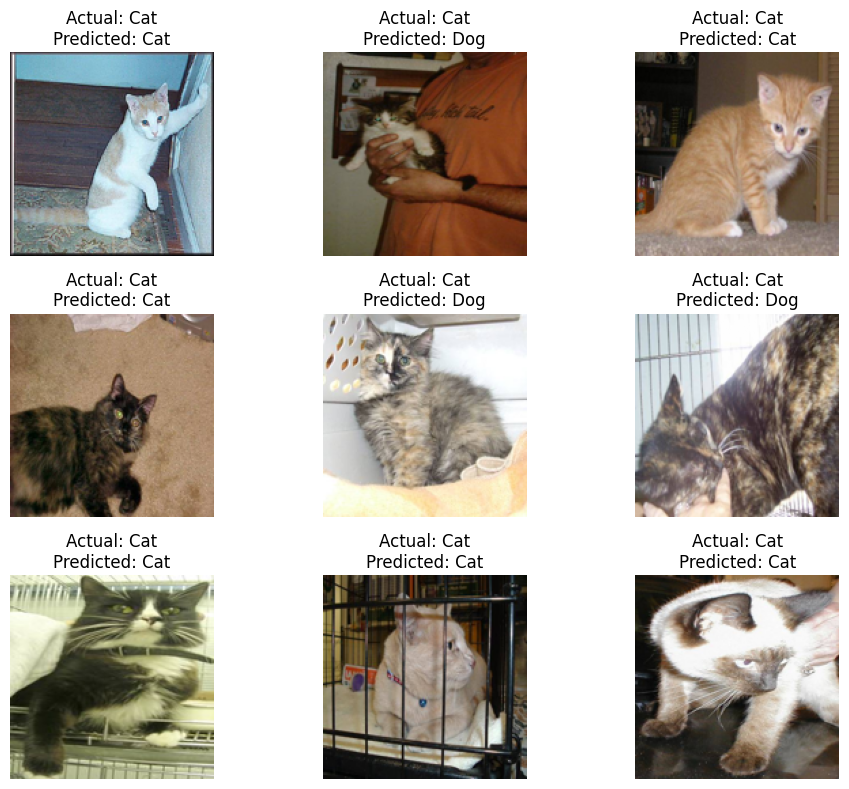

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from datasets import load_dataset
from tensorflow.keras import layers, models

dataset = load_dataset("Bingsu/Cat_and_Dog")

train_hf = dataset["train"]
test_hf = dataset["test"]

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

def preprocess(example):
    image = example["image"].convert("RGB")
    image = image.resize(IMG_SIZE)
    image = np.array(image, dtype=np.float32) / 255.0
    return image

x_train = np.array([preprocess(x) for x in train_hf])
y_train = np.array(train_hf["labels"])

x_test = np.array([preprocess(x) for x in test_hf])
y_test = np.array(test_hf["labels"])

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)

plt.figure(figsize=(8, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i])
    plt.title("Cat" if y_train[i] == 0 else "Dog")
    plt.axis("off")

plt.tight_layout()
plt.show()

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),

    layers.Dense(1, activation="sigmoid")
])

model.summary()

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=BATCH_SIZE,
    validation_split=0.2
)

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    batch_size=BATCH_SIZE
)

print("\nFinal Results")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

predictions = model.predict(x_test[:9])

plt.figure(figsize=(10, 8))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    plt.imshow(x_test[i])

    predicted = "Dog" if predictions[i][0] >= 0.5 else "Cat"
    actual = "Dog" if y_test[i] == 1 else "Cat"

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# New Section

In [ ]:
!git config --global user.name "Manas-Siddharth"

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9889 - loss: 0.0354 - val_accuracy: 0.9899 - val_loss: 0.0339
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9913 - loss: 0.0280 - val_accuracy: 0.9892 - val_loss: 0.0357
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9934 - loss: 0.0213 - val_accuracy: 0.9868 - val_loss: 0.0445
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9949 - loss: 0.0174 - val_accuracy: 0.9889 - val_loss: 0.0372
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9958 - loss: 0.0148 - val_accuracy: 0.9869 - val_loss: 0.0439
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9959 - loss: 0.0129 - val_accuracy: 0.9851 - val_loss: 0.0476
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9969 - loss: 0.0101 - val_accuracy: 0.9805 - val_loss: 0.0675
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9974 - loss: 0.0087 - 

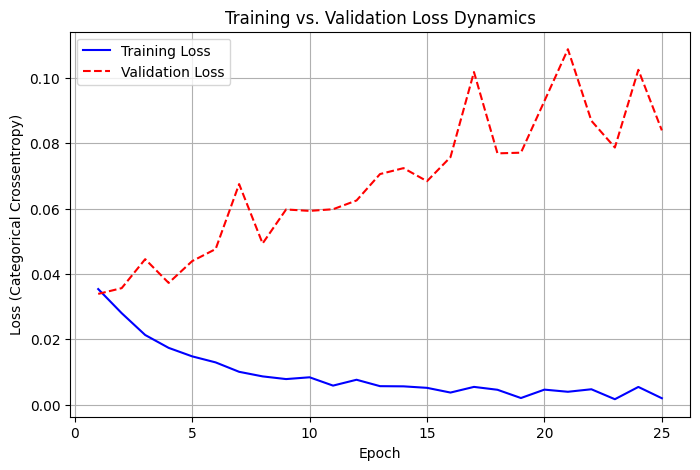

In [ ]:
import matplotlib.pyplot as plt

# 1. Train the model while reserving a portion (e.g., 20%) of data for validation.
# Increasing the epochs helps illustrate the point where overfitting begins.
history = model.fit(x_train, y_train,
                    epochs=25,
                    validation_split=0.2,
                    verbose=1)

# 2. Extract the loss metrics from the training history
training_loss = history.history['loss']
validation_loss = history.history['val_loss']
epochs_range = range(1, len(training_loss) + 1)

# 3. Plot Training vs. Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, training_loss, 'b-', label='Training Loss')
plt.plot(epochs_range, validation_loss, 'r--', label='Validation Loss')
plt.title('Training vs. Validation Loss Dynamics')
plt.xlabel('Epoch')
plt.ylabel('Loss (Categorical Crossentropy)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import tensorflow as tf

# 1. Load the Dataset
# To classify clothing instead, change this to: tf.keras.datasets.fashion_mnist
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. Normalize the images to a pixel range of 0 to 1
x_train, x_test = x_train / 255.0, x_test / 255.0

# 3. Build the Neural Network Architecture
model = tf.keras.models.Sequential([
    # Flatten the 28x28 pixel images into a 1D array of 784 pixels
    tf.keras.layers.Flatten(input_shape=(28, 28)),

    # Hidden layer with 128 neurons and ReLU activation
    tf.keras.layers.Dense(128, activation='relu'),

    # OUTPUT LAYER: 10 neurons (one for each class 0-9) using Softmax
    tf.keras.layers.Dense(10, activation='softmax')
])

# 4. Compile the Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. Train the Model
print("Training on the dataset...")
model.fit(x_train, y_train, epochs=5)

# 6. Evaluate Accuracy
print("\nEvaluating on test data...")
test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training on the dataset...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9257 - loss: 0.2588
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9668 - loss: 0.1118
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9777 - loss: 0.0768
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9824 - loss: 0.0577
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9863 - loss: 0.0447

Evaluating on test data...
313/313 - 1s - 3ms/step - accuracy: 0.9749 - loss: 0.0798

Final Test Accuracy: 0.9749
